# ObesityIQ — simple complete notebook

Read the explanation, run the short code cell, then read its output. This notebook follows the same small-cell style as the laptop and credit-card projects.

## 1. Understand the project before writing code

We use health and lifestyle information to predict **one of seven current weight categories**. This is supervised classification: training rows already have correct labels. It is multi-class because there are seven possible answers. It is not a prediction of future obesity or a clinical diagnosis.

We ask two questions: Which of three classifiers works best? Can fewer original input fields give an acceptable result?

The provided dataset has 20,958 rows and 18 columns before cleaning: **16 inputs + `id` + `NObeyesdad`**. `id` identifies a row. `NObeyesdad` is the answer, called the target.

| Input column | Meaning | Type used in code |
|---|---|---|
| Gender | Reported gender | Categorical |
| Age | Age | Numerical |
| Height | Height in metres | Numerical |
| Weight | Weight in kilograms | Numerical |
| family_history_with_overweight | Family history of overweight | Categorical |
| FAVC | Frequent high-calorie food consumption | Categorical |
| FCVC | Vegetable consumption frequency | Numerical |
| NCP | Number of main meals | Numerical |
| CAEC | Eating between meals | Categorical |
| SMOKE | Smoking | Categorical |
| CH2O | Water intake | Numerical |
| SCC | Monitoring calorie consumption | Categorical |
| FAF | Physical activity frequency | Numerical |
| TUE | Time using technology devices | Numerical |
| CALC | Alcohol consumption | Categorical |
| MTRANS | Transport mode | Categorical |

Several habits are recorded as numerical scores, not direct physical measurements. We use their supplied values; we do not claim they are exact hours, litres or counts for every generated record.

The target categories are Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II and Obesity_Type_III.

**Dataset note:** This file is a modified version of the original obesity dataset. Missing entries and 200 exact duplicate rows were introduced for cleaning practice. This is the only data-provenance note needed; do not describe those issues as defects of the original source.

**Run instructions:** Keep this notebook beside `train(3).csv`. It also accepts `train.csv`. Requirements: pandas, numpy, matplotlib, seaborn and scikit-learn. Run from top to bottom.

## 2. Import tools and load the file

An import makes a tool available. It does not clean data or train anything. Pandas works with tables, NumPy works with arrays, and Matplotlib/Seaborn draw plots. We import model tools in their own sections.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

data_file = 'train(3).csv' if Path('train(3).csv').exists() else 'train.csv'
df = pd.read_csv(data_file)
df.head()

      id  Gender        Age   Height      Weight family_history_with_overweight FAVC     FCVC  NCP       CAEC SMOKE      CH2O SCC       FAF       TUE       CALC                 MTRANS           NObeyesdad
0   9258  Female  18.260079  1.64603   41.706283                             no  yes  2.13683  1.0  Sometimes    no  1.000000  no  0.061366  1.253311  Sometimes  Public_Transportation  Insufficient_Weight
1  14987    Male  23.000000  1.72000   75.000000                            yes  yes  2.00000  3.0  Sometimes    no  2.000000  no  1.000000  2.000000  Sometimes  Public_Transportation   Overweight_Level_I
2  12789    Male  23.975685  1.86741  121.864326                            yes  yes  3.00000  3.0  Sometimes    no  2.000000  no  1.289421  0.000000  Sometimes  Public_Transportation      Obesity_Type_II
3  15962  Female  25.895546  1.73421  104.988925                            yes  yes  3.00000  3.0  Sometimes    no  1.031354  no  0.210351  0.779641  Sometimes                    

`read_csv` creates a DataFrame named `df`. `head()` displays the first five rows so we can see the table layout. It does not establish that the whole file is correct. Next we check shape, names, types and numerical summaries.

In [2]:
print('Rows and columns:', df.shape)
print('Column names:', df.columns.tolist())
df.info()

Rows and columns: (20958, 18)
Column names: ['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20958 entries, 0 to 20957
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20958 non-null  int64  
 1   Gender                          20958 non-null  object 
 2   Age                             20538 non-null  float64
 3   Height                          20958 non-null  float64
 4   Weight                          20958 non-null  float64
 5   family_history_with_overweight  20539 non-null  object 
 6   FAVC                            20958 non-null  object 
 7   FCVC                            20433 non-null  float64
 8   NCP                             20958 non-null  float

In [3]:
df.describe().round(2)

             id       Age    Height    Weight      FCVC       NCP      CH2O       FAF       TUE
count  20958.00  20538.00  20958.00  20958.00  20433.00  20958.00  20958.00  20327.00  20958.00
mean   10377.28     23.85      1.70     87.90      2.45      2.76      2.03      0.98      0.62
std     5989.27      5.69      0.09     26.38      0.53      0.71      0.61      0.84      0.60
min        0.00     14.00      1.45     39.00      1.00      1.00      1.00      0.00      0.00
25%     5192.25     20.00      1.63     66.00      2.00      3.00      1.80      0.01      0.00
50%    10376.50     22.82      1.70     84.13      2.40      3.00      2.00      1.00      0.57
75%    15563.75     26.00      1.76    111.64      3.00      3.00      2.55      1.59      1.00
max    20757.00     61.00      1.98    165.06      3.00      4.00      3.00      3.00      2.00


`info()` shows each column type and non-missing count. `describe()` gives numerical summaries such as minimum, maximum and median. These checks help us understand the file; they do not fill or remove values.

## 3. Detect exact duplicates and remove them immediately

`duplicated()` checks every column, including the identifier and target. It marks repeated occurrences after the first as True. `sum()` counts them. We inspect example repeats, then remove them. Two people with similar measurements are not automatically duplicates.

In [4]:
print('Exact duplicate rows:', df.duplicated().sum())
df[df.duplicated()].head()

Exact duplicate rows: 200
         id  Gender        Age    Height      Weight family_history_with_overweight FAVC      FCVC      NCP        CAEC SMOKE      CH2O SCC       FAF       TUE        CALC                 MTRANS          NObeyesdad
2487   6506  Female  19.693804  1.627839  133.852432                            NaN  yes  3.000000  3.00000   Sometimes    no  2.721356  no  1.465909  0.620465   Sometimes  Public_Transportation    Obesity_Type_III
3097  11724  Female  26.000000  1.634894  111.216192                            yes  yes  3.000000  3.00000   Sometimes    no  2.709140  no  0.000000  0.723154   Sometimes  Public_Transportation    Obesity_Type_III
3510  13802    Male  23.260061  1.755938  119.201465                            yes  yes  2.357496  3.00000   Sometimes    no  2.156870  no  1.076729  0.000000   Sometimes  Public_Transportation     Obesity_Type_II
3649  17161    Male  21.000000  1.790000   78.000000                            yes  yes  2.000000  1.00000  Frequ

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print('Rows after removal:', len(df))
print('Remaining exact duplicates:', df.duplicated().sum())

Rows after removal: 20758
Remaining exact duplicates: 0


We keep the first occurrence of each exact row. Resetting the DataFrame index only creates consecutive row positions; it does not change the `id` values. Remove duplicates before splitting so the same copied record cannot appear in both training and testing.

Alternative: checking selected columns can find other kinds of repeated records, but choosing them requires a reason. We do not remove rows just because age and weight match.

## 4. Check missing values and the target

`isna()` marks missing cells. `sum()` counts them in each column. This check tells us what needs filling. The target has no missing values in this file; we never fill missing labels using a feature-imputation rule.

**Balanced and imbalanced classes:** Balanced means each class has about the same number of rows. Imbalanced means some classes have more rows than others. For example, 500 normal-weight rows and 50 overweight rows are imbalanced. A model could favour the larger class, so accuracy alone may hide poor results for the smaller one.

In this dataset the class counts differ, but every class has many examples. We preserve class proportions with stratified splits and compare models with Macro F1, which gives each class equal weight. These steps do not balance the data. We do not apply class weights or resampling here. Those are possible alternatives to compare using cross-validation if smaller classes perform poorly.


In [6]:
print('Missing values by column:')
print(df.isna().sum())
print('\nTarget class counts:')
print(df['NObeyesdad'].value_counts())

Missing values by column:
id                                  0
Gender                              0
Age                               415
Height                              0
Weight                              0
family_history_with_overweight    415
FAVC                                0
FCVC                              519
NCP                                 0
CAEC                                0
SMOKE                               0
CH2O                                0
SCC                                 0
FAF                               623
TUE                                 0
CALC                                0
MTRANS                            415
NObeyesdad                          0
dtype: int64

Target class counts:
NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


Why not fill missing values from the whole table now? The median or most common category would include information from future test rows. Instead, we first split the data, then define filling as the first operation in each model pipeline. This small ordering detail protects the evaluation.

Deleting every incomplete row is an alternative, but it discards useful values in the other columns. Median/mode filling is a simple approach here; it does not reconstruct a person's true missing answer.

## 5. Separate inputs from the correct answer

`X` contains the 16 inputs. `y` contains their correct weight categories. We exclude the target so the model cannot read the answer, and exclude `id` because it is a row identifier. No new features or BMI column are created.

In [7]:
X = df.drop(columns=['id', 'NObeyesdad'])
y = df['NObeyesdad']

numeric_columns = X.select_dtypes(include='number').columns.tolist()
category_columns = X.select_dtypes(exclude='number').columns.tolist()

print('Number of inputs:', X.shape[1])
print('Numerical columns:', numeric_columns)
print('Categorical columns:', category_columns)

Number of inputs: 16
Numerical columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


## 6. Split once, with a clear job for each part

| Part | Approximate share | Job |
|---|---:|---|
| Training | 60% | Model comparison by cross-validation, then training feature experiments |
| Validation A | 10% | Rank original inputs using shuffling |
| Validation B | 10% | Choose how many ranked inputs to keep |
| Test | 20% | Final check after choices are fixed |

Training + A + B together are the **development data** (80%). A and B have different jobs so we do not choose a feature count using the same rows that supplied the importance ranking. A single validation set is a simpler alternative, but its use for both steps can favour the choices made on those rows.

`stratify=y` keeps roughly the same class proportions. `random_state` makes the split repeatable. The shares are design choices, not universal requirements.

In [8]:
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=43)

X_A, X_B, y_A, y_B = train_test_split(
    X_validation, y_validation, test_size=0.50,
    stratify=y_validation, random_state=44)

print('Training:', len(X_train))
print('Validation A:', len(X_A))
print('Validation B:', len(X_B))
print('Test:', len(X_test))

Training: 12454
Validation A: 2076
Validation B: 2076
Test: 4152


The helper selects column **types**, not values or labels. `handle_unknown='ignore'` lets prediction proceed if a new category was absent in training. Manual `fillna` and `get_dummies` are alternatives, but would need careful repetition inside every cross-validation fold and matching columns at prediction time.

## 7. Small EDA on training rows

EDA means looking at patterns before interpreting model results. We use training rows to examine class sizes and average measurements. Pandas skips missing numerical entries in these summaries; they are still filled by the pipeline before modelling. We do not fill the whole dataset just to make these plots.

Higher weight in heavier categories is expected. Correlation describes association, not medical cause. We do not assign arbitrary numeric codes to the seven classes and correlate those codes as if they were measured quantities.

**Read the helper in order:**
1. `columns` is the list of original fields we want to use.
2. `numbers` and `categories` divide those fields by their data type.
3. `number_steps` fills numerical gaps. When `scale=True`, it also scales numerical values.
4. `category_steps` fills categorical gaps and converts categories into indicator columns.
5. `preparation` applies the right steps to each group of columns.
6. The returned pipeline performs preparation first and model fitting second.

For example, one-hot encoding a transport field with Bus, Car and Walking creates separate indicator columns. A Bus row has 1 in the Bus column and 0 in the others. This avoids suggesting that Car is numerically greater than Bus.

**Scaling example:** Height may be around 1.7, while weight may be around 80. StandardScaler puts numerical fields on a common scale using training means and standard deviations. It does not turn kilograms into metres.

**When does filling actually happen?** Calling this helper only defines the steps. During `fit`, the pipeline learns the median and most common category from the rows used for fitting. During `predict`, it uses those same learned values. Cross-validation fits a separate pipeline in every fold, so preprocessing is learned from that fold's training rows only.


Mean height and weight by class:
                     Height  Weight
NObeyesdad                         
Insufficient_Weight    1.68   49.78
Normal_Weight          1.67   61.57
Obesity_Type_I         1.69   92.40
Obesity_Type_II        1.78  116.12
Obesity_Type_III       1.68  117.60
Overweight_Level_I     1.69   74.21
Overweight_Level_II    1.71   82.02


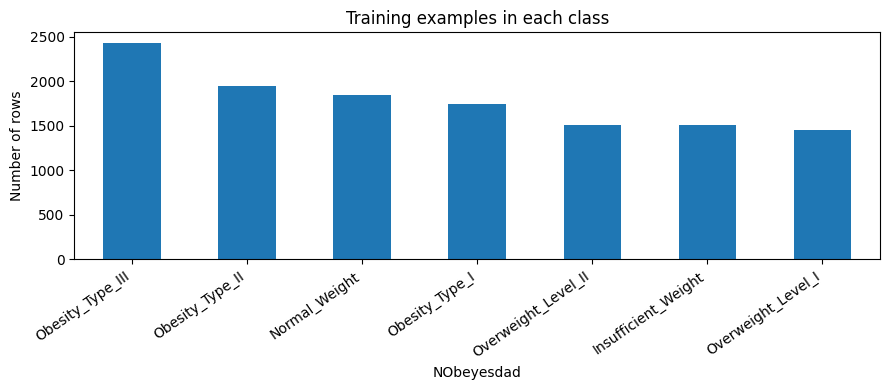

In [9]:
eda = X_train.copy()
eda['NObeyesdad'] = y_train

print('Mean height and weight by class:')
print(eda.groupby('NObeyesdad')[['Height', 'Weight']].mean().round(2))

plt.figure(figsize=(9, 4))
y_train.value_counts().plot(kind='bar')
plt.title('Training examples in each class')
plt.ylabel('Number of rows')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

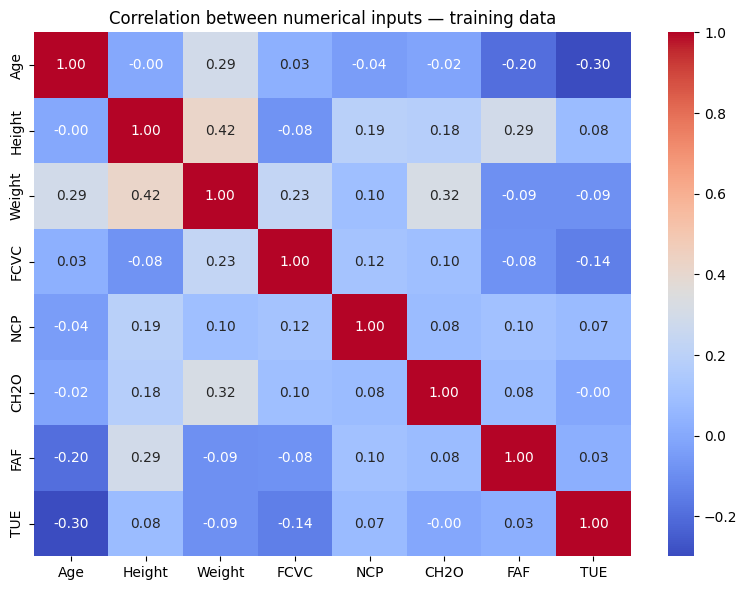

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_train[numeric_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between numerical inputs — training data')
plt.tight_layout()
plt.show()

The second split takes 25% of the 80% development portion, so it sets aside 20% of the original rows. Dividing that part in half gives A and B about 10% each.

## 8. Define missing-value filling and encoding

Numerical columns: fill with the **training median** (middle value), which is less affected by extreme values than the mean. Categorical columns: fill with the **training most common category**, then apply one-hot encoding. One-hot creates indicator columns, avoiding an invented order between transport modes or other categories.

For Logistic Regression, also standardize numerical values: subtract the training mean and divide by the training standard deviation. This helps optimization and keeps its regularization from depending on the original units. Decision Tree and Random Forest use threshold splits, so they do not need this scaling.

`ColumnTransformer` sends numerical and categorical columns through the appropriate steps. `Pipeline` keeps those steps with the model. During cross-validation, each fold learns filling, encoding and scaling from its own training rows. Defining a pipeline does not fit it yet.

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# This small helper keeps the same preparation in every experiment.
def make_pipeline(columns, model, scale=False):
    numbers = X[columns].select_dtypes(include='number').columns.tolist()
    categories = X[columns].select_dtypes(exclude='number').columns.tolist()

    number_steps = [('fill', SimpleImputer(strategy='median'))]
    if scale:
        number_steps.append(('scale', StandardScaler()))

    category_steps = [('fill', SimpleImputer(strategy='most_frequent')),
                      ('encode', OneHotEncoder(handle_unknown='ignore'))]

    preparation = ColumnTransformer([
        ('numbers', Pipeline(number_steps), numbers),
        ('categories', Pipeline(category_steps), categories)
    ])
    return Pipeline([('preparation', preparation), ('model', model)])

## 9. Define the three classifiers

| Model | Why include it? | Main limitation here |
|---|---|---|
| Logistic Regression | Simple linear-score classification baseline | Can miss nonlinear relationships |
| Decision Tree | Learns if/else rules and interactions | Can memorize training data if too deep |
| Random Forest | Combines many trees to reduce instability | More computation and harder to explain as one rule |

Logistic Regression is suitable for a categorical target despite its name. We allow up to 2,000 optimization iterations. Tree depth is limited to control complexity. The forest uses 200 trees, maximum depth 15 and at least five examples to consider splitting a node. These are fixed settings, not the result of a large tuning search. No claim that every model assumption has been verified.

**How each model predicts:** Logistic Regression calculates a score for each class from the inputs, turns these scores into probabilities, and chooses the class with the highest probability. A Decision Tree follows learned questions such as “Is weight below this threshold?” until it reaches a leaf; it predicts the most common training class in that leaf. A leaf does not have to contain only one class. Random Forest combines class probabilities from many trees and predicts the class with the highest average probability.

**Relevant assumptions:** Logistic Regression uses linear class scores; it does not require the inputs to be normally distributed. It may miss relationships that need more complex boundaries. Trees and forests do not require linear relationships or normally distributed inputs. All three still need useful labels and data that represent the people on whom we want to predict. Removing copied rows helps avoid obvious repeated-record contamination, but it does not prove that the dataset represents every population.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

all_columns = X.columns.tolist()

logistic = make_pipeline(all_columns, LogisticRegression(max_iter=2000), scale=True)
tree = make_pipeline(all_columns,
                     DecisionTreeClassifier(max_depth=10, random_state=42))
forest = make_pipeline(all_columns,
                       RandomForestClassifier(n_estimators=200, max_depth=15,
                                              min_samples_split=5,
                                              random_state=42, n_jobs=-1))

## 10. Compare models by cross-validation on training data

Split the training portion into three folds. Fit on two and check on the remaining fold; repeat three times. The comparison uses the average scores on those held-out folds, not scores on the exact rows the model just learned from.

| Metric | Meaning |
|---|---|
| Accuracy | Fraction of predictions that are correct |
| Macro precision | Average class precision: among predicted members of a class, how many were correct? |
| Macro recall | Average class recall: among actual members of a class, how many were found? |
| Macro F1 | Average of the seven class F1 scores; each balances precision and recall |

We choose by **mean Macro F1** so each category gets equal weight. We still display all four metrics. Three folds balance repeat checking and runtime; five folds would be another reasonable choice. The final test is not used to select the model.

**A simple three-fold example:** Divide the training rows into groups 1, 2 and 3. First train on groups 2 and 3 and evaluate group 1. Next train on 1 and 3 and evaluate 2. Finally train on 1 and 2 and evaluate 3. Average the three evaluation scores. This gives each training row a turn as an unseen validation example. `StratifiedKFold` keeps similar class proportions in each group.

**Why not select from training accuracy?** A model can memorise the rows it was fitted on. The held-out fold scores show how well it predicts rows it did not fit on. Model selection therefore uses validation scores within the training portion, not its fitted-row accuracy.


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'precision': 'precision_macro',
           'recall': 'recall_macro', 'f1': 'f1_macro'}
models = {'Logistic Regression': logistic, 'Decision Tree': tree,
          'Random Forest': forest}

comparison = []
for name, model in models.items():
    result = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    comparison.append([name, result['test_accuracy'].mean(),
                       result['test_precision'].mean(), result['test_recall'].mean(),
                       result['test_f1'].mean()])

model_results = pd.DataFrame(comparison,
    columns=['Model', 'Accuracy', 'Macro precision', 'Macro recall', 'Macro F1'])
model_results = model_results.sort_values('Macro F1', ascending=False)
print(model_results.round(4).to_string(index=False))

best_name = model_results.iloc[0]['Model']
print('\nSelected model:', best_name)

              Model  Accuracy  Macro precision  Macro recall  Macro F1
      Random Forest    0.8831           0.8725        0.8694    0.8699
      Decision Tree    0.8577           0.8440        0.8438    0.8438
Logistic Regression    0.8542           0.8373        0.8390    0.8377

Selected model: Random Forest


Random Forest has the highest mean CV Macro F1 in the saved run (0.8699), compared with 0.8438 for Decision Tree and 0.8377 for Logistic Regression. We therefore use the selected model in the next experiments. The word `test_` in scikit-learn's CV output means the held-out **fold**, not our final test dataset.

## 11. Fit the selected full model and inspect its imputation

`clone` gives us a fresh pipeline with the selected settings. Calling `fit` first learns preprocessing on training rows and then trains the classifier. Here we also print the medians used for numerical missing values. This makes the cleaning step visible rather than simply saying it happened.

In [14]:
from sklearn.base import clone

full_model = clone(models[best_name])
full_model.fit(X_train, y_train)

number_imputer = full_model.named_steps['preparation'].named_transformers_['numbers'].named_steps['fill']
category_imputer = full_model.named_steps['preparation'].named_transformers_['categories'].named_steps['fill']
print('Numerical fill values:')
print(pd.Series(number_imputer.statistics_, index=numeric_columns))
print('\nCategorical fill values:')
print(pd.Series(category_imputer.statistics_, index=category_columns))

Numerical fill values:
Age       22.777890
Height     1.700000
Weight    84.000000
FCVC       2.392665
NCP        3.000000
CH2O       2.000000
FAF        1.000000
TUE        0.561602
dtype: float64

Categorical fill values:
Gender                                           Female
family_history_with_overweight                      yes
FAVC                                                yes
CAEC                                          Sometimes
SMOKE                                                no
SCC                                                  no
CALC                                          Sometimes
MTRANS                            Public_Transportation
dtype: object


## 12. Rank original columns using Validation A

Permutation importance means this experiment: measure normal Macro F1, shuffle one input's values among validation rows, predict with the unchanged model, and measure the score drop. Keep labels and the other columns unchanged. Restore that column before testing another. Repeat each shuffle three times and average the drop.

For example, shuffling weight pairs a person's other information with someone else's weight. **No retraining or feature deletion occurs during this step.** We are measuring how much this fitted model relies on the correct values of each original input. A large drop means strong reliance. Correlated inputs can share importance, so a small drop does not prove an input is useless. This is not PCA and it does not establish cause.

**What does shuffled mean?** Suppose three weights are 50, 80 and 110. Shuffling might rearrange them to 110, 50 and 80. The values remain in the weight column, but they are now attached to different people. Age, height, other fields and correct class labels stay in their original rows. We compare predictions before and after this change.

**What is the drop?** If normal Macro F1 is 0.88 and shuffled Macro F1 is 0.83, the importance for that shuffle is 0.88 − 0.83 = 0.05. The table below reports measured average drops, not invented example values.


In [15]:
from sklearn.metrics import f1_score
from sklearn.inspection import permutation_importance

baseline_A = f1_score(y_A, full_model.predict(X_A), average='macro')
importance = permutation_importance(full_model, X_A, y_A, scoring='f1_macro',
                                    n_repeats=3, random_state=42)

ranking = pd.Series(importance.importances_mean, index=all_columns)
ranking = ranking.sort_values(ascending=False)
print('Normal Validation A Macro F1:', round(baseline_A, 4))
print('\nAverage Macro F1 drop after shuffling:')
print(ranking.round(4))

Normal Validation A Macro F1: 0.879

Average Macro F1 drop after shuffling:
Weight                            0.5519
Gender                            0.1713
Height                            0.0639
Age                               0.0352
family_history_with_overweight    0.0173
CALC                              0.0173
CH2O                              0.0102
NCP                               0.0102
CAEC                              0.0092
FAVC                              0.0091
FCVC                              0.0079
MTRANS                            0.0056
FAF                               0.0045
TUE                               0.0028
SCC                               0.0005
SMOKE                             0.0005
dtype: float64


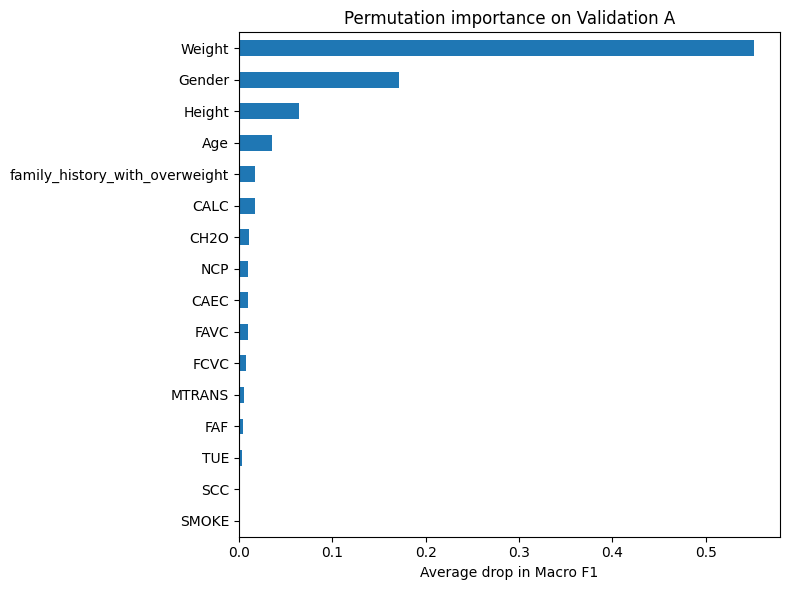

In [16]:
ranking.sort_values().plot(kind='barh', figsize=(8, 6))
plt.xlabel('Average drop in Macro F1')
plt.title('Permutation importance on Validation A')
plt.tight_layout()
plt.show()

## 13. Retrain with different feature counts on Validation B

Ranking tells us the order, not how many to retain. Try the top **4, 6, 8, 10, 12 and 16** original columns. For every count, create a new pipeline, train on the same training rows, and predict Validation B. Retraining happens here.

Before inspecting B, use this rule: choose the smallest tried count with Macro F1 no more than **0.005 below** the full model's Validation B score. That is a half-percentage-point tolerance, chosen as a practical tradeoff. It is not a statistical test or a universal optimum. More columns do not always improve a separately trained model.

We define one short metric helper so all comparison tables show the same four scores.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate(actual, predicted):
    return [accuracy_score(actual, predicted),
            precision_score(actual, predicted, average='macro', zero_division=0),
            recall_score(actual, predicted, average='macro', zero_division=0),
            f1_score(actual, predicted, average='macro', zero_division=0)]

In [18]:
feature_comparison = []
for count in [4, 6, 8, 10, 12, 16]:
    columns = ranking.index[:count].tolist()
    classifier = clone(models[best_name].named_steps['model'])
    smaller_model = make_pipeline(columns, classifier,
                                  scale=(best_name == 'Logistic Regression'))
    smaller_model.fit(X_train[columns], y_train)
    predictions = smaller_model.predict(X_B[columns])
    feature_comparison.append([count] + evaluate(y_B, predictions))

feature_results = pd.DataFrame(feature_comparison,
    columns=['Features', 'Accuracy', 'Macro precision', 'Macro recall', 'Macro F1'])
full_B_score = feature_results.loc[feature_results['Features'] == 16, 'Macro F1'].iloc[0]
feature_results['F1 loss vs 16'] = full_B_score - feature_results['Macro F1']
print(feature_results.round(4).to_string(index=False))

 Features  Accuracy  Macro precision  Macro recall  Macro F1  F1 loss vs 16
        4    0.8868           0.8755        0.8748    0.8751         0.0021
        6    0.8815           0.8691        0.8698    0.8694         0.0078
        8    0.8873           0.8756        0.8761    0.8758         0.0014
       10    0.8839           0.8731        0.8722    0.8724         0.0048
       12    0.8849           0.8743        0.8726    0.8731         0.0041
       16    0.8887           0.8789        0.8767    0.8772         0.0000


In [19]:
allowed_loss = 0.005
acceptable = feature_results[feature_results['F1 loss vs 16'] <= allowed_loss]
selected_count = int(acceptable['Features'].min())
selected_columns = ranking.index[:selected_count].tolist()

print('Selected number:', selected_count)
print('Selected columns:', selected_columns)
print('Reduction in original inputs:', (16 - selected_count) / 16 * 100, '%')

Selected number: 4
Selected columns: ['Weight', 'Gender', 'Height', 'Age']
Reduction in original inputs: 75.0 %


### Why did four columns win in this run?

The full model's Validation B Macro F1 is **0.8772**. Subtracting the allowed loss, 0.005, gives a minimum acceptable score of **0.8722**. Four columns score **0.8751**, so their drop is only **0.0021**. Four is the smallest of the tested counts and meets the rule. Eight columns score slightly better than four on B, but the rule prefers fewer inputs as long as the tolerance is met.

The selected original inputs are **Weight, Gender, Height and Age**. The reduction is (16 − 4) / 16 × 100 = **75%**. This is fewer required input fields, not a measured 75% saving in money or runtime. It also does not mean four encoded columns: gender can become multiple one-hot columns.

We did not know four would be selected in advance. We did not try every possible subset or counts below four, so we cannot call it the globally optimal number. A and B support the choice; the final test will check how it behaves on unseen rows.

**Why feature selection rather than PCA?** PCA means Principal Component Analysis. It combines numerical inputs into new columns called principal components, chosen to preserve variation in the inputs. Our goal is to collect fewer original fields. Four PCA components calculated from all sixteen fields would generally still need all sixteen fields for a new person. Selecting Weight, Gender, Height and Age directly lets the person supply only those four fields.


## 14. Final training and held-out test evaluation

Choices are now fixed. Refit the selected model with four columns and a full 16-column reference on all 80% development rows. Predict the same untouched test rows once for each version. The test reports performance; it did not choose the classifier or feature count. A test comparison is allowed when the choices were fixed beforehand.

The four-column choice may lose more on test than on validation. That is a finding to report honestly, not a reason to change the tolerance using test results.

In [20]:
test_comparison = []
for version, columns in [('Four-feature', selected_columns), ('Full 16', all_columns)]:
    classifier = clone(models[best_name].named_steps['model'])
    final_model = make_pipeline(columns, classifier,
                                scale=(best_name == 'Logistic Regression'))
    final_model.fit(X_dev[columns], y_dev)
    predictions = final_model.predict(X_test[columns])
    test_comparison.append([version, len(columns)] + evaluate(y_test, predictions))

    if version == 'Four-feature':
        compact_model = final_model
        compact_predictions = predictions

test_results = pd.DataFrame(test_comparison,
    columns=['Version', 'Features', 'Accuracy', 'Macro precision', 'Macro recall', 'Macro F1'])
print(test_results.round(4).to_string(index=False))

     Version  Features  Accuracy  Macro precision  Macro recall  Macro F1
Four-feature         4    0.8803           0.8678        0.8673    0.8675
     Full 16        16    0.8904           0.8814        0.8778    0.8785


### What is the final conclusion?

The compact model has **88.03% test accuracy and 0.8675 Macro F1**. The full model has **89.04% accuracy and 0.8785 Macro F1**. Accuracy decreases by **1.01 percentage points**, and Macro F1 decreases by about **1.10 percentage points**. The four-input model met the validation rule but did not preserve identical performance on test.

The result shows a tradeoff: fewer measurements/questions versus stronger prediction. We have not demonstrated deployment, clinical usefulness or a measured runtime saving.

## 15. Check individual classes and mistakes

Overall accuracy can hide a weak class. The report shows precision, recall and F1 for every category. `support` is the number of actual test rows in that class. The confusion matrix has actual classes as rows and predicted classes as columns. Diagonal cells are correct; other cells are mistakes.

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.91      0.91       505
      Normal_Weight       0.84      0.85      0.85       617
     Obesity_Type_I       0.86      0.86      0.86       582
    Obesity_Type_II       0.95      0.96      0.96       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.75      0.72      0.74       485
Overweight_Level_II       0.75      0.77      0.76       504

           accuracy                           0.88      4152
          macro avg       0.87      0.87      0.87      4152
       weighted avg       0.88      0.88      0.88      4152



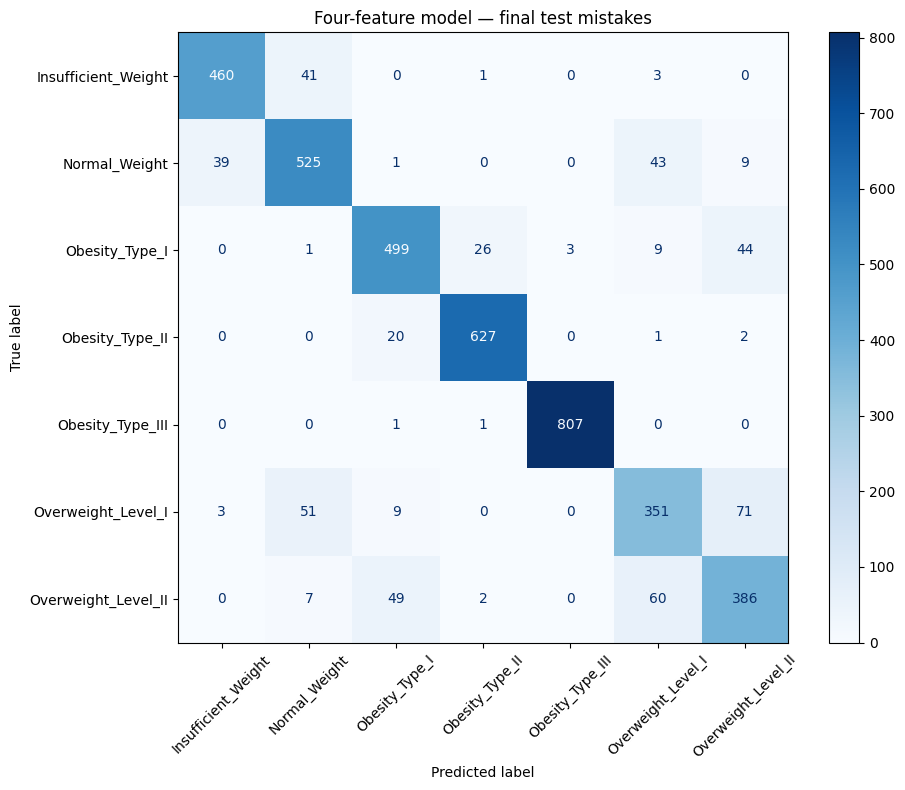

In [21]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, compact_predictions, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, compact_predictions,
                                       cmap='Blues', xticks_rotation=45, ax=ax)
plt.title('Four-feature model — final test mistakes')
plt.tight_layout()
plt.show()

Overweight level I and II have lower scores than several other categories in this test. Some mistakes occur between nearby weight categories. The report identifies this limitation; the notebook does not implement a separate method to solve it.

## 16. Use the fitted model for a new record

A new input needs the same original fields, with the same names and units. The pipeline applies the already learned filling/encoding steps automatically. Below is an illustrative record, not a real person's diagnosis. We do not retrain on this one row.

In [22]:
new_record = pd.DataFrame({'Weight': [80.0], 'Gender': ['Male'],
                           'Height': [1.75], 'Age': [25.0]})
print('Predicted category:', compact_model.predict(new_record[selected_columns])[0])

Predicted category: Overweight_Level_II


## 17. Explain your four CV lines

**Line 1 — data preparation:** I checked the table, removed exact repeated rows, filled missing inputs inside training-only preprocessing, and one-hot encoded categories. This is preprocessing, not creation of new features.

**Line 2 — model comparison:** I compared Logistic Regression, Decision Tree and Random Forest using three stratified folds of the training portion. Random Forest had the highest average Macro F1; final test scores were not used for that selection.

**Line 3 — 75% fewer inputs:** Permutation importance ranked inputs on A. Fresh models with different counts were compared on B. Four original fields met the 0.005 validation Macro F1 tolerance. Twelve of sixteen fields were removed, which is 75% fewer original inputs.

**Line 4 — final comparison:** The compact and full Random Forest versions were trained on development rows and evaluated on held-out test rows. Compact accuracy was 88.03%, compared with 89.04% for all inputs. Both numbers describe evaluation, not training on test data.

### Interview answer: Explain your project

“I worked on seven-class weight-category prediction using over 20,000 health and lifestyle records. I inspected the dataset, removed exact duplicates, and used a preprocessing pipeline to handle missing values and categorical inputs. I compared Logistic Regression, Decision Tree and Random Forest through three-fold stratified cross-validation on the training portion and selected Random Forest by average Macro F1. Then I asked whether fewer inputs were sufficient. I ranked the original inputs using permutation importance on Validation A, retrained with different feature counts, and used Validation B to choose the smallest count within a 0.005 Macro F1 tolerance of the full model. Four inputs—weight, gender, height and age—met that rule. The final test accuracy was 88.03% with four inputs versus 89.04% with all sixteen. So I found a simpler input option, with a measurable loss in prediction performance.”

If asked about the origin of the missing values or duplicates, explain the dataset note at the beginning. If asked why weight is included, explain that the goal here is current category classification; predicting without measuring weight is a different experiment.